# CNN + Grad-CAM — Detecção de Fissuras em Concreto
**Dataset:** Surface Crack Detection (Kaggle — arunrk7)  
**Técnicas:** Transfer Learning · Data Augmentation · Ablation Study · Grad-CAM  
**Versão:** Google Colab

### Células
| # | Conteúdo |
|---|----------|
| 0 | Configurar Kaggle e baixar dataset |
| 1 | Configurações globais |
| 2 | Dependências e importações |
| 3 | Carregar e dividir dataset (80/10/10) |
| 4 | Normalização e augmentation |
| 5 | Funções auxiliares (treino e avaliação completa) |
| 6 | Modelo A — sem augmentation, sem fine-tuning |
| 7 | Modelo B — com augmentation, sem fine-tuning |
| 8 | Modelo C — com augmentation + fine-tuning |
| 9 | Ablation Study: tabela, curvas de treino, matrizes de confusão |
| 10 | Grad-CAM — layout horizontal para o artigo |
| 11 | Resumo final e download |


In [1]:
# ============================================================
# CÉLULA 0 — Configurar Kaggle e baixar dataset
# ============================================================

from google.colab import files
files.upload()  # selecione o arquivo kaggle.json

import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install -q kaggle
!kaggle datasets download -d arunrk7/surface-crack-detection
!unzip -q surface-crack-detection.zip -d crack_dataset
!ls crack_dataset/

for classe in ['Negative', 'Positive']:
    caminho = f"crack_dataset/{classe}"
    n = len(os.listdir(caminho))
    print(f"  {classe}: {n} imagens")


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
100% 233M/233M [00:02<00:00, 116MB/s] 

Negative  Positive
  Negative: 20000 imagens
  Positive: 20000 imagens


In [2]:
# ============================================================
# CÉLULA 1 — Configurações globais
# ============================================================

import os

PASTA_DATASET  = "crack_dataset"
PASTA_SAIDA    = "resultados_crack"
CLASSES        = ["Negative", "Positive"]

TAMANHO_IMAGEM = 224    # MobileNetV2 espera 224×224
BATCH_SIZE     = 32
EPOCHS_FASE1   = 10     # cabeça congelada
EPOCHS_FASE2   = 10     # fine-tuning
SEED           = 42

os.makedirs(PASTA_SAIDA, exist_ok=True)
print("Configurações:")
print(f"  Dataset  : {PASTA_DATASET}")
print(f"  Saída    : {PASTA_SAIDA}")
print(f"  Classes  : {CLASSES}")
print(f"  Imagem   : {TAMANHO_IMAGEM}×{TAMANHO_IMAGEM}")
print(f"  Batch    : {BATCH_SIZE}")


Configurações:
  Dataset  : crack_dataset
  Saída    : resultados_crack
  Classes  : ['Negative', 'Positive']
  Imagem   : 224×224
  Batch    : 32


In [3]:
# ============================================================
# CÉLULA 2 — Dependências e importações
# ============================================================

!pip install -q scikit-learn seaborn pillow opencv-python

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ============================================================
# CÉLULA 3 — Carregar e dividir dataset (80/10/10)
# ============================================================

print("── Coletando arquivos ───────────────────────────────")

caminhos, rotulos = [], []
for idx, classe in enumerate(CLASSES):
    pasta = Path(PASTA_DATASET) / classe
    imgs  = list(pasta.glob("*.jpg")) + list(pasta.glob("*.png"))
    for img in imgs:
        caminhos.append(str(img))
        rotulos.append(idx)

caminhos = np.array(caminhos)
rotulos  = np.array(rotulos)
total    = len(caminhos)

print(f"  Total de imagens : {total}")
for i, c in enumerate(CLASSES):
    print(f"  {c:<12} : {np.sum(rotulos==i)}")

# 80% treino | 20% temporário
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    caminhos, rotulos, test_size=0.20,
    random_state=SEED, stratify=rotulos)

# 10% validação | 10% teste
X_val, X_tst, y_val, y_tst = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    random_state=SEED, stratify=y_tmp)

print(f"\n  Treino    : {len(X_tr):>6} ({len(X_tr)/total*100:.0f}%)")
print(f"  Validação : {len(X_val):>6} ({len(X_val)/total*100:.0f}%)")
print(f"  Teste     : {len(X_tst):>6} ({len(X_tst)/total*100:.0f}%)")

# Verificação do balanço por classe em cada split
for nome, X, y in [("Treino", X_tr, y_tr),
                    ("Validação", X_val, y_val),
                    ("Teste", X_tst, y_tst)]:
    for i, c in enumerate(CLASSES):
        print(f"  {nome} — {c}: {np.sum(y==i)}")


── Coletando arquivos ───────────────────────────────
  Total de imagens : 40000
  Negative     : 20000
  Positive     : 20000

  Treino    :  32000 (80%)
  Validação :   4000 (10%)
  Teste     :   4000 (10%)
  Treino — Negative: 16000
  Treino — Positive: 16000
  Validação — Negative: 2000
  Validação — Positive: 2000
  Teste — Negative: 2000
  Teste — Positive: 2000


In [5]:
# ============================================================
# CÉLULA 4 — Normalização e augmentation
# ============================================================

# Gerador COM augmentation (Modelos B e C — só no treino)
gen_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode="reflect"
)

# Gerador SEM augmentation (Modelo A, validação e teste)
gen_simples = ImageDataGenerator(rescale=1.0/255)

def criar_gerador(gen, caminhos_arr, rotulos_arr,
                  batch=BATCH_SIZE, shuffle=True):
    df = pd.DataFrame({
        "filename": caminhos_arr,
        "class":    [CLASSES[r] for r in rotulos_arr]
    })
    return gen.flow_from_dataframe(
        df, x_col="filename", y_col="class",
        target_size=(TAMANHO_IMAGEM, TAMANHO_IMAGEM),
        batch_size=batch, class_mode="categorical",
        classes=CLASSES, shuffle=shuffle, seed=SEED
    )

gen_tr_aug     = criar_gerador(gen_aug,     X_tr,  y_tr)
gen_tr_simples = criar_gerador(gen_simples, X_tr,  y_tr)
gen_val        = criar_gerador(gen_simples, X_val, y_val, shuffle=False)
gen_tst        = criar_gerador(gen_simples, X_tst, y_tst, shuffle=False)

steps_tr  = len(X_tr)  // BATCH_SIZE
steps_val = len(X_val) // BATCH_SIZE

print(f"  Steps/época treino    : {steps_tr}")
print(f"  Steps/época validação : {steps_val}")
print("\nAugmentation: rotação ±20°, flip H/V, zoom ±15%, shift ±10%, brilho ±15%")


Found 32000 validated image filenames belonging to 2 classes.
Found 32000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
  Steps/época treino    : 1000
  Steps/época validação : 125

Augmentation: rotação ±20°, flip H/V, zoom ±15%, shift ±10%, brilho ±15%


In [6]:
# ============================================================
# CÉLULA 5 — Funções auxiliares
# ============================================================

N_CLASSES = len(CLASSES)

def construir_modelo(fine_tuning=False, nome="modelo"):
    base = MobileNetV2(
        input_shape=(TAMANHO_IMAGEM, TAMANHO_IMAGEM, 3),
        include_top=False, weights="imagenet"
    )
    if fine_tuning:
        base.trainable = True
        for camada in base.layers[:-30]:
            camada.trainable = False
        lr = 1e-5
    else:
        base.trainable = False
        lr = 1e-4

    inp   = Input(shape=(TAMANHO_IMAGEM, TAMANHO_IMAGEM, 3))
    x     = base(inp, training=fine_tuning)
    x     = layers.GlobalAveragePooling2D()(x)
    x     = layers.Dense(256, activation="relu")(x)
    x     = layers.Dropout(0.5)(x)
    saida = layers.Dense(N_CLASSES, activation="softmax")(x)

    modelo = models.Model(inputs=inp, outputs=saida, name=nome)
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

def callbacks_padrao(nome):
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(PASTA_SAIDA, f"{nome}.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=0)
    ]

def salvar_history(hist, nome_arquivo):
    """Salva o history do Keras em JSON para recuperar sem retreinar."""
    caminho = os.path.join(PASTA_SAIDA, nome_arquivo)
    with open(caminho, "w") as f:
        json.dump(hist.history, f, indent=2)
    print(f"  History salvo: {nome_arquivo}")

def avaliar_modelo(modelo, gen_teste, y_true, nome):
    """
    Avalia o modelo e retorna dicionário com todas as métricas:
    Accuracy, Precision, Sensitivity (Recall), Specificity, F1-Score.
    """
    gen_teste.reset()
    y_prob = modelo.predict(gen_teste, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Confusion matrix → TN, FP, FN, TP
    cm_vals = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_vals.ravel()

    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    precision   = TP / (TP + FP)   if (TP + FP) > 0 else 0.0
    sensitivity = TP / (TP + FN)   if (TP + FN) > 0 else 0.0  # Recall Positive
    specificity = TN / (TN + FP)   if (TN + FP) > 0 else 0.0  # Recall Negative
    f1          = (2 * precision * sensitivity /
                   (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0.0)

    relatorio = classification_report(
        y_true, y_pred, target_names=CLASSES, digits=3)

    print(f"\n{'─'*55}")
    print(f"  {nome}")
    print(f"{'─'*55}")
    print(f"  Accuracy    : {accuracy*100:.2f}%")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Sensitivity : {sensitivity:.4f}  (Recall — Positive)")
    print(f"  Specificity : {specificity:.4f}  (Recall — Negative)")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"\n{relatorio}")

    return {
        "nome": nome,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "relatorio": relatorio
    }

print("Funções auxiliares definidas.")


Funções auxiliares definidas.


In [7]:
# ============================================================
# CÉLULA 6 — MODELO A: Sem augmentation, sem fine-tuning
# ============================================================

print("="*55)
print("  MODELO A — Sem Augmentation | Sem Fine-tuning")
print("="*55)

modelo_a = construir_modelo(fine_tuning=False, nome="modelo_a")

hist_a = modelo_a.fit(
    gen_tr_simples,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_a"),
    verbose=1
)

# ── Salvar history para plotar curvas depois sem retreinar ────
salvar_history(hist_a, "history_A.json")

gen_tst.reset()
resultado_a = avaliar_modelo(modelo_a, gen_tst, y_tst, "Modelo A")


  MODELO A — Sem Augmentation | Sem Fine-tuning
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 43ms/step - accuracy: 0.9907 - loss: 0.0270 - val_accuracy: 0.9962 - val_loss: 0.0089 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9977 - val_loss: 0.0079 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.9977 - loss: 0.0072 - val_accuracy: 0.9970 - val_loss: 0.0066 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9973 - val_loss: 0.0062 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.9984 - loss: 0.0048 - val_accuracy: 0.9977 - val_loss: 0.0065 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.9986 - loss: 0.0043 - val_accurac

In [8]:
# ============================================================
# CÉLULA 7 — MODELO B: Com augmentation, sem fine-tuning
# ============================================================

print("="*55)
print("  MODELO B — Com Augmentation | Sem Fine-tuning")
print("="*55)

modelo_b = construir_modelo(fine_tuning=False, nome="modelo_b")

hist_b = modelo_b.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_b"),
    verbose=1
)

# ── Salvar history ────────────────────────────────────────────
salvar_history(hist_b, "history_B.json")

gen_tst.reset()
resultado_b = avaliar_modelo(modelo_b, gen_tst, y_tst, "Modelo B")


  MODELO B — Com Augmentation | Sem Fine-tuning
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 395s 387ms/step - accuracy: 0.9866 - loss: 0.0375 - val_accuracy: 0.9962 - val_loss: 0.0105 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 385s 385ms/step - accuracy: 0.9960 - loss: 0.0144 - val_accuracy: 0.9962 - val_loss: 0.0081 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 388s 388ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9967 - val_loss: 0.0082 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 386s 386ms/step - accuracy: 0.9968 - loss: 0.0100 - val_accuracy: 0.9952 - val_loss: 0.0137 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 383s 383ms/step - accuracy: 0.9971 - loss: 0.0102 - val_accuracy: 0.9973 - val_loss: 0.0067 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 376s 376ms/step - accuracy: 0.9969 - loss: 0.0093 - val_accuracy: 0.9980 - val_loss: 0.0068 - learni

In [9]:
# ============================================================
# CÉLULA 8 — MODELO C: Com augmentation + fine-tuning
# ============================================================

print("="*55)
print("  MODELO C — Com Augmentation + Fine-tuning")
print("="*55)

# ── Fase 1: backbone congelado ────────────────────────────────
print("\n  Fase 1: backbone congelado...")
modelo_c = construir_modelo(fine_tuning=False, nome="modelo_c_f1")

hist_c1 = modelo_c.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_padrao("modelo_c_f1"),
    verbose=1
)

# ── Salvar history da fase 1 ──────────────────────────────────
salvar_history(hist_c1, "history_C1.json")

# ── Fase 2: fine-tuning das últimas 30 camadas ────────────────
print("\n  Fase 2: fine-tuning (últimas 30 camadas)...")
base_c = modelo_c.layers[1]   # MobileNetV2 é a segunda camada
base_c.trainable = True
for camada in base_c.layers[:-30]:
    camada.trainable = False

modelo_c.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hist_c2 = modelo_c.fit(
    gen_tr_aug,
    steps_per_epoch=steps_tr,
    validation_data=gen_val,
    validation_steps=steps_val,
    epochs=EPOCHS_FASE2,
    callbacks=callbacks_padrao("modelo_c_final"),
    verbose=1
)

# ── Salvar history da fase 2 ──────────────────────────────────
salvar_history(hist_c2, "history_C2.json")

gen_tst.reset()
resultado_c = avaliar_modelo(modelo_c, gen_tst, y_tst, "Modelo C")


  MODELO C — Com Augmentation + Fine-tuning

  Fase 1: backbone congelado...
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 401s 393ms/step - accuracy: 0.9895 - loss: 0.0308 - val_accuracy: 0.9965 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 383s 383ms/step - accuracy: 0.9961 - loss: 0.0129 - val_accuracy: 0.9967 - val_loss: 0.0080 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 386s 386ms/step - accuracy: 0.9967 - loss: 0.0116 - val_accuracy: 0.9967 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 392s 392ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9975 - val_loss: 0.0074 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 383s 383ms/step - accuracy: 0.9971 - loss: 0.0090 - val_accuracy: 0.9973 - val_loss: 0.0062 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 392s 392ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.996

  ABLATION STUDY — RESULTADOS

Modelo Augmentation Fine-tuning  Accuracy (%)  Precision  Sensitivity  Specificity  F1-Score
     A          Não         Não         99.88     0.9990       0.9985       0.9990    0.9987
     B          Sim         Não         99.82     0.9975       0.9990       0.9975    0.9983
     C          Sim         Sim         99.85     0.9990       0.9980       0.9990    0.9985


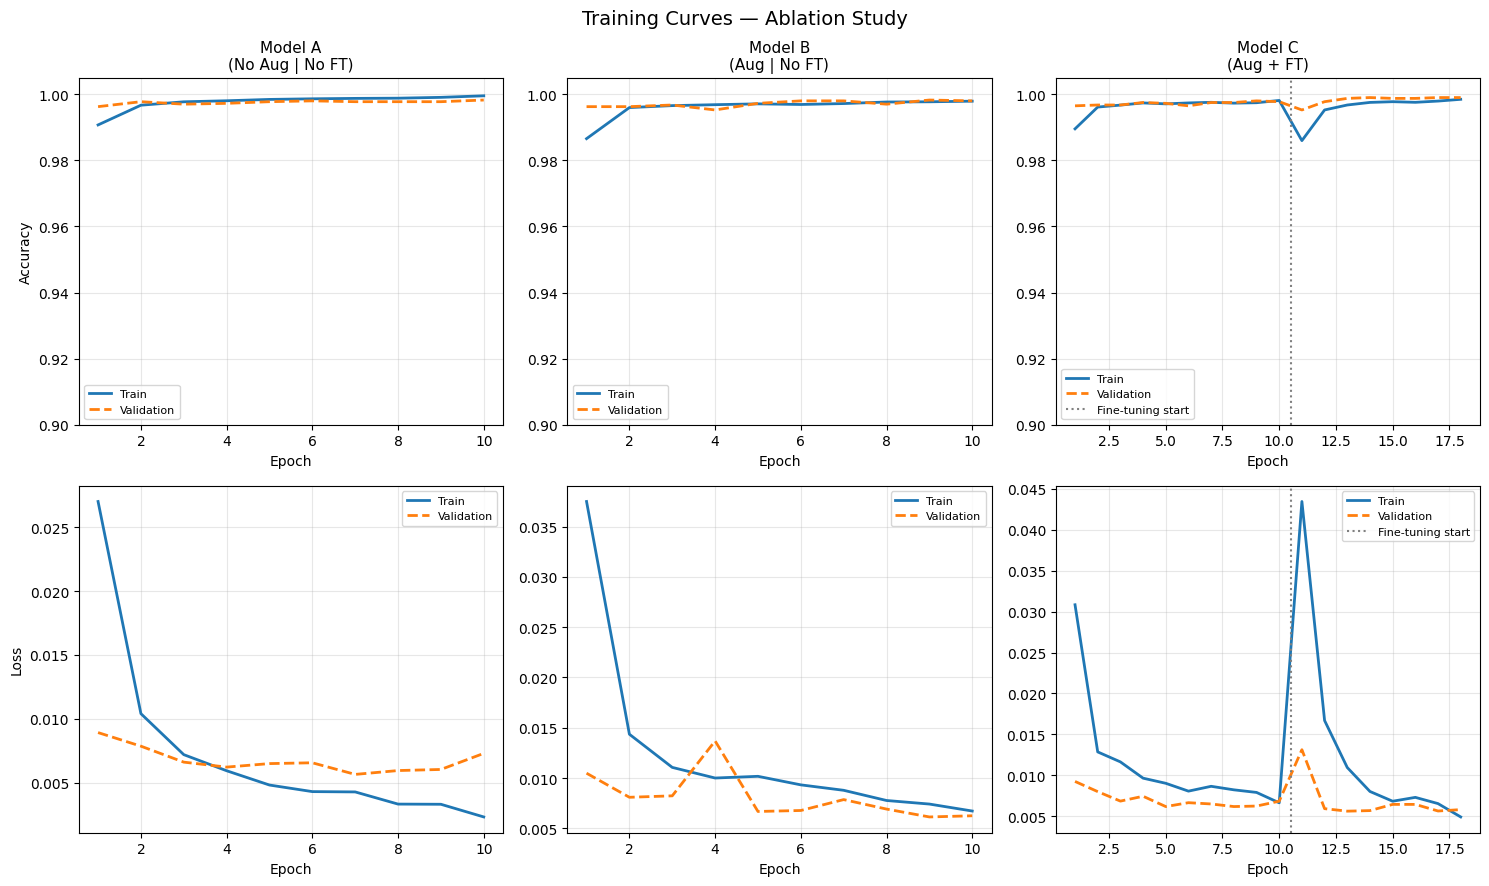

Curvas de treinamento salvas: training_curves.png


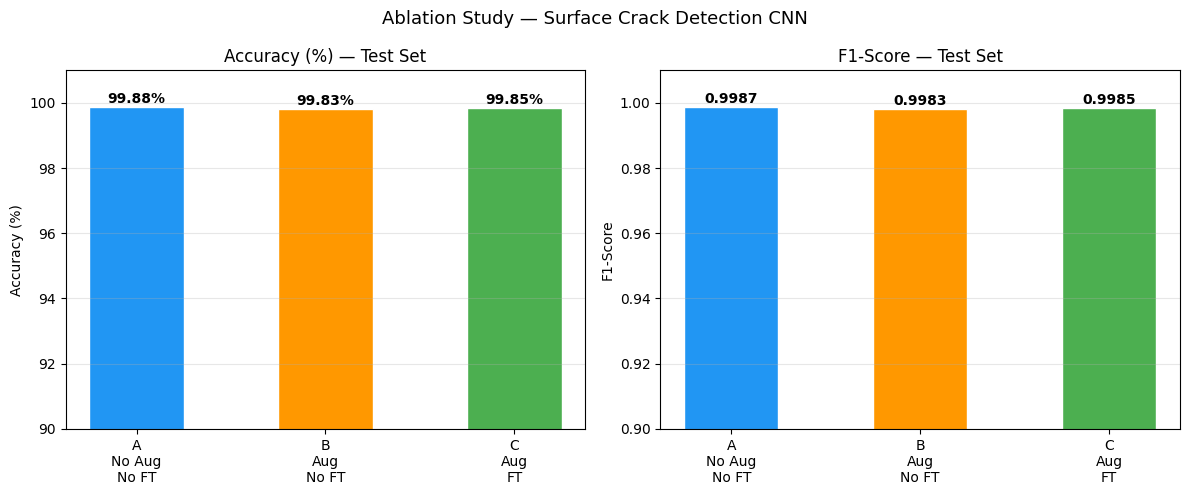

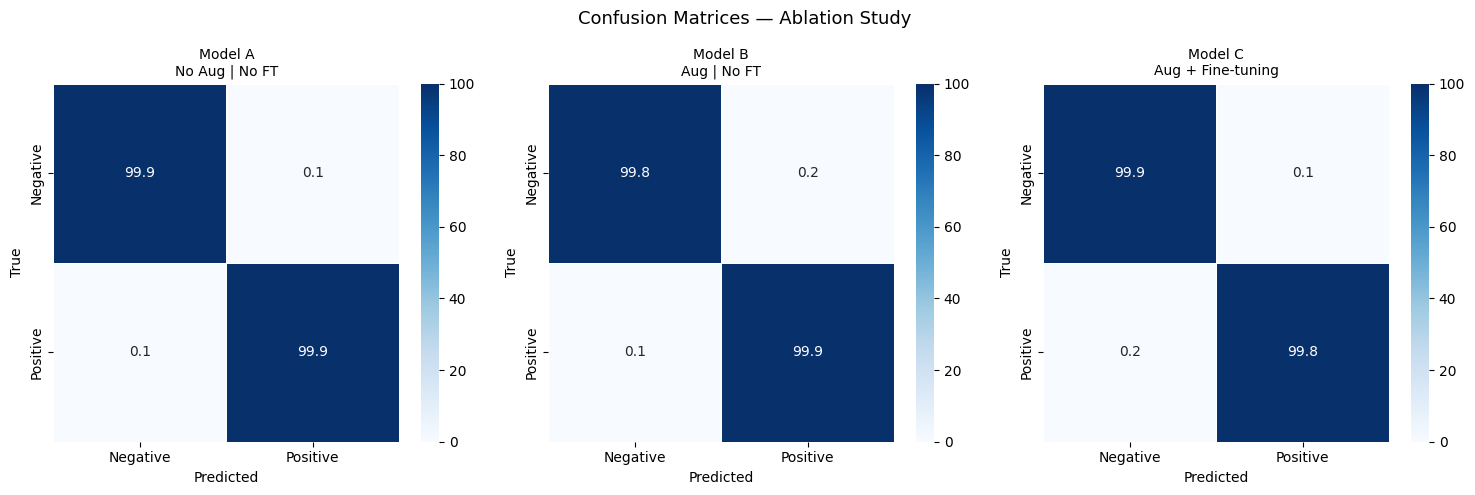

Todos os gráficos do Ablation Study salvos.


In [10]:
# ============================================================
# CÉLULA 9 — Ablation Study: tabela, curvas de treino, matrizes
# ============================================================

print("="*55)
print("  ABLATION STUDY — RESULTADOS")
print("="*55)

# ── 9.1 Tabela completa com todas as métricas ─────────────────
tabela = pd.DataFrame([
    {"Modelo": "A", "Augmentation": "Não", "Fine-tuning": "Não",
     "Accuracy (%)":  round(resultado_a["accuracy"]*100, 2),
     "Precision":     round(resultado_a["precision"],    4),
     "Sensitivity":   round(resultado_a["sensitivity"],  4),
     "Specificity":   round(resultado_a["specificity"],  4),
     "F1-Score":      round(resultado_a["f1"],           4)},
    {"Modelo": "B", "Augmentation": "Sim", "Fine-tuning": "Não",
     "Accuracy (%)":  round(resultado_b["accuracy"]*100, 2),
     "Precision":     round(resultado_b["precision"],    4),
     "Sensitivity":   round(resultado_b["sensitivity"],  4),
     "Specificity":   round(resultado_b["specificity"],  4),
     "F1-Score":      round(resultado_b["f1"],           4)},
    {"Modelo": "C", "Augmentation": "Sim", "Fine-tuning": "Sim",
     "Accuracy (%)":  round(resultado_c["accuracy"]*100, 2),
     "Precision":     round(resultado_c["precision"],    4),
     "Sensitivity":   round(resultado_c["sensitivity"],  4),
     "Specificity":   round(resultado_c["specificity"],  4),
     "F1-Score":      round(resultado_c["f1"],           4)},
])

print("\n" + tabela.to_string(index=False))
tabela.to_csv(os.path.join(PASTA_SAIDA, "ablation_tabela.csv"),
              index=False, encoding="utf-8-sig")

# Salvar relatório
with open(os.path.join(PASTA_SAIDA, "ablation_relatorio.txt"), "w") as f:
    f.write("=== ABLATION STUDY — CRACK DETECTION ===\n\n")
    f.write(f"Dataset   : Surface Crack Detection (Kaggle)\n")
    f.write(f"Split     : 80/10/10\n")
    f.write(f"Treino    : {len(X_tr)} | Val : {len(X_val)} | Teste : {len(X_tst)}\n\n")
    f.write(tabela.to_string(index=False))
    f.write("\n\n")
    for res in [resultado_a, resultado_b, resultado_c]:
        f.write(f"\n{'─'*50}\n{res['nome']}\n{res['relatorio']}")

# ── 9.2 Curvas de treinamento (Accuracy e Loss) ───────────────
# Carrega histories salvos em JSON para garantir consistência
def carregar_history(nome_arquivo):
    caminho = os.path.join(PASTA_SAIDA, nome_arquivo)
    with open(caminho) as f:
        return json.load(f)

h_a  = carregar_history("history_A.json")
h_b  = carregar_history("history_B.json")
h_c1 = carregar_history("history_C1.json")
h_c2 = carregar_history("history_C2.json")

# Concatena as duas fases do Modelo C
h_c = {
    "accuracy":     h_c1["accuracy"]     + h_c2["accuracy"],
    "val_accuracy": h_c1["val_accuracy"] + h_c2["val_accuracy"],
    "loss":         h_c1["loss"]         + h_c2["loss"],
    "val_loss":     h_c1["val_loss"]     + h_c2["val_loss"],
}
split_c = len(h_c1["accuracy"])  # época onde começa o fine-tuning

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Training Curves — Ablation Study", fontsize=14)

configs = [
    (h_a,  "Model A\n(No Aug | No FT)", None),
    (h_b,  "Model B\n(Aug | No FT)",    None),
    (h_c,  "Model C\n(Aug + FT)",       split_c),
]

for col, (h, titulo, split) in enumerate(configs):
    epocas = range(1, len(h["accuracy"]) + 1)

    # Linha de cima: Accuracy
    ax_acc = axes[0, col]
    ax_acc.plot(epocas, h["accuracy"],     label="Train", linewidth=2)
    ax_acc.plot(epocas, h["val_accuracy"], label="Validation",
                linewidth=2, linestyle="--")
    if split:
        ax_acc.axvline(split + 0.5, color="gray", linestyle=":",
                       linewidth=1.5, label="Fine-tuning start")
    ax_acc.set_title(titulo, fontsize=11)
    ax_acc.set_ylabel("Accuracy" if col == 0 else "")
    ax_acc.set_xlabel("Epoch")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.90, 1.005)

    # Linha de baixo: Loss
    ax_loss = axes[1, col]
    ax_loss.plot(epocas, h["loss"],     label="Train", linewidth=2)
    ax_loss.plot(epocas, h["val_loss"], label="Validation",
                 linewidth=2, linestyle="--")
    if split:
        ax_loss.axvline(split + 0.5, color="gray", linestyle=":",
                        linewidth=1.5, label="Fine-tuning start")
    ax_loss.set_ylabel("Loss" if col == 0 else "")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Curvas de treinamento salvas: training_curves.png")

# ── 9.3 Gráfico de barras comparativo ────────────────────────
resultados = [resultado_a, resultado_b, resultado_c]
modelos    = ["A\nNo Aug\nNo FT", "B\nAug\nNo FT", "C\nAug\nFT"]
cores      = ["#2196F3", "#FF9800", "#4CAF50"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Ablation Study — Surface Crack Detection CNN", fontsize=13)

for ax, chave, titulo, ylabel, ylim, fmt in [
    (ax1, "accuracy", "Accuracy (%) — Test Set", "Accuracy (%)", (90, 101),
     lambda v: f"{v*100:.2f}%"),
    (ax2, "f1",       "F1-Score — Test Set",     "F1-Score",     (0.90, 1.01),
     lambda v: f"{v:.4f}"),
]:
    vals = [r[chave] for r in resultados]
    bars = ax.bar(modelos, [v if chave == "f1" else v*100
                            for v in vals],
                  color=cores, edgecolor="white", width=0.5)
    ax.set_title(titulo); ax.set_ylabel(ylabel)
    ax.set_ylim(ylim); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (ylim[1]-ylim[0])*0.01,
                fmt(v), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "ablation_comparativo.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── 9.4 Matrizes de confusão ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Confusion Matrices — Ablation Study", fontsize=13)

for ax, res, titulo in zip(
    axes,
    resultados,
    ["Model A\nNo Aug | No FT", "Model B\nAug | No FT", "Model C\nAug + Fine-tuning"]
):
    cm_mat = confusion_matrix(y_tst, res["y_pred"])
    cm_pct = cm_mat.astype(float) / cm_mat.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f",
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap="Blues", ax=ax, linewidths=0.5, vmin=0, vmax=100)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(PASTA_SAIDA, "ablation_matrizes.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Todos os gráficos do Ablation Study salvos.")


Calculando Grad-CAM para Positive corretos...
  Positive corretos: 1996 | Scores top-4: [0.194, 0.194, 0.153, 0.153]
Calculando Grad-CAM para Negative corretos...
Gerando figura Grad-CAM horizontal...


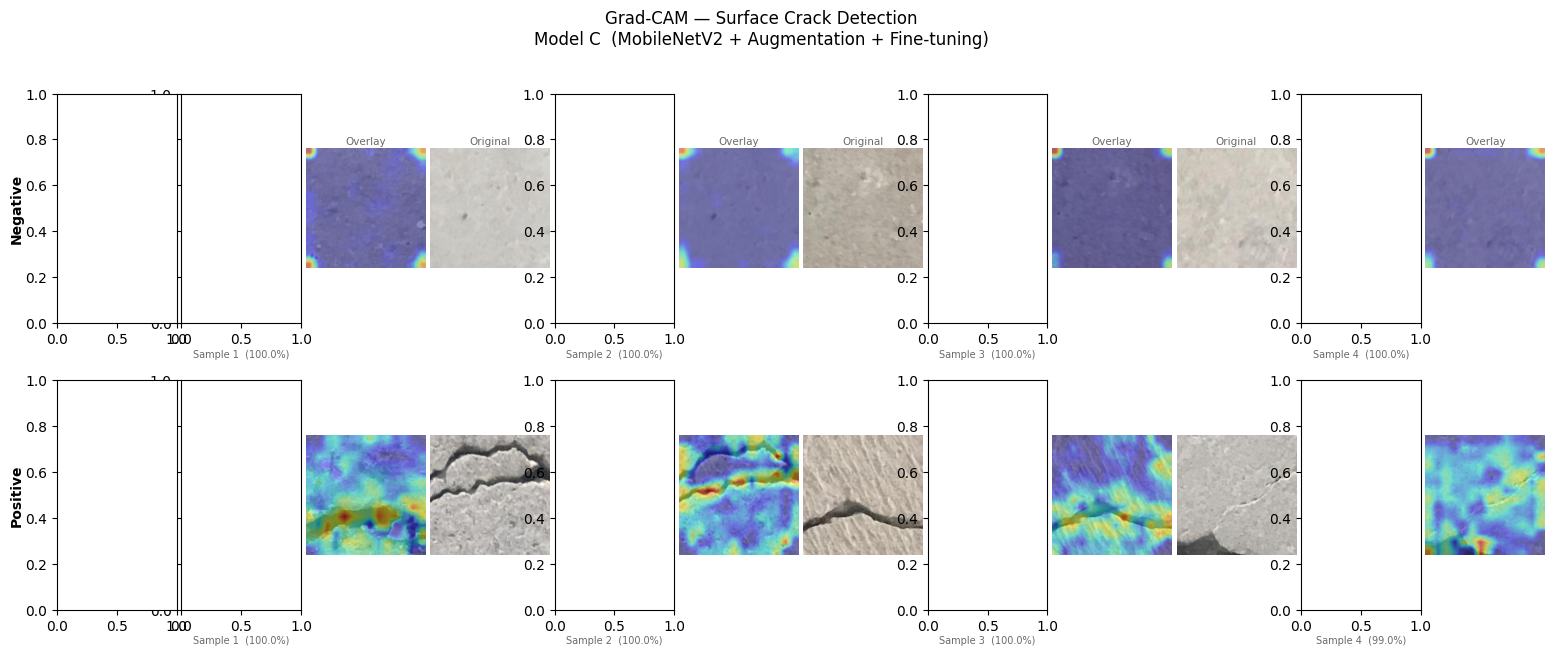

gradcam_final.png salvo.


In [12]:
# ============================================================
# CÉLULA 10 — Grad-CAM (layout horizontal para o artigo)
# ============================================================
# Layout: 2 linhas (Negative / Positive) × 4 amostras × 3 colunas
# → figura com proporção wide, adequada para figure* em 2 colunas

def gerar_gradcam(modelo, img_array, camadas_candidatas=None):
    if camadas_candidatas is None:
        camadas_candidatas = [
            "block_13_expand_relu",
            "block_12_expand_relu",
            "block_11_expand_relu",
        ]

    # Localiza o backbone MobileNetV2
    backbone = next(
        l for l in modelo.layers
        if isinstance(l, tf.keras.Model)
    )

    nomes = {l.name for l in backbone.layers}
    camada_alvo = next(
        (c for c in camadas_candidatas if c in nomes), None
    )
    if camada_alvo is None:
        raise ValueError("Nenhuma camada candidata encontrada.")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(camada_alvo).output,
                 backbone.output]
    )

    # ── Recupera camadas da cabeça por tipo, não por nome ────────
    gap_layer      = next(l for l in modelo.layers
                          if isinstance(l, tf.keras.layers.GlobalAveragePooling2D))
    dense_layers   = [l for l in modelo.layers
                      if isinstance(l, tf.keras.layers.Dense)]
    dropout_layer  = next(l for l in modelo.layers
                          if isinstance(l, tf.keras.layers.Dropout))
    dense_hidden   = dense_layers[0]   # Dense(256, relu)
    dense_output   = dense_layers[1]   # Dense(2, softmax)

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_out, bb_out = grad_model(img_tensor)
        tape.watch(conv_out)

        x = gap_layer(bb_out)
        x = dense_hidden(x)
        x = dropout_layer(x, training=False)
        preds = dense_output(x)
        pred_idx = int(tf.argmax(preds[0]))
        loss = preds[:, pred_idx]

    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_idx, preds.numpy()[0]

def sobrepor_gradcam(img_original, heatmap, alpha=0.45):
    h, w   = img_original.shape[:2]
    hm_res = cv2.resize(heatmap, (w, h))
    hm_col = cm.jet(hm_res)[:, :, :3]
    overlay = (1 - alpha) * img_original + alpha * hm_col
    return np.clip(overlay, 0, 1)

def score_heatmap(heatmap, threshold=0.5):
    """Fração de pixels com ativação normalizada > threshold."""
    return float(np.mean(heatmap > threshold))

def carregar_imagem(caminho):
    img = Image.open(caminho).convert("RGB")
    img = img.resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM))
    return np.array(img, dtype=np.float32) / 255.0

# ── Fase 1: Positive — selecionar 4 com maior ativação ────────
print("Calculando Grad-CAM para Positive corretos...")

idx_pos = [i for i in range(len(y_tst))
           if y_tst[i] == 1 and resultado_c["y_pred"][i] == 1]

resultados_pos = []
for idx in idx_pos:
    img_arr   = carregar_imagem(X_tst[idx])
    img_input = img_arr[np.newaxis, ...]
    heatmap, pred_idx, probs = gerar_gradcam(modelo_c, img_input)
    resultados_pos.append({
        "idx": idx, "img_arr": img_arr, "heatmap": heatmap,
        "pred_idx": pred_idx, "probs": probs,
        "score": score_heatmap(heatmap)
    })

resultados_pos.sort(key=lambda x: x["score"], reverse=True)
melhores_pos = resultados_pos[:4]
print(f"  Positive corretos: {len(idx_pos)} | "
      f"Scores top-4: {[round(r['score'],3) for r in melhores_pos]}")

# ── Fase 2: Negative — selecionar 4 aleatoriamente ────────────
print("Calculando Grad-CAM para Negative corretos...")

idx_neg = [i for i in range(len(y_tst))
           if y_tst[i] == 0 and resultado_c["y_pred"][i] == 0]
idx_neg_sel = np.random.choice(idx_neg, 4, replace=False)

melhores_neg = []
for idx in idx_neg_sel:
    img_arr   = carregar_imagem(X_tst[idx])
    img_input = img_arr[np.newaxis, ...]
    heatmap, pred_idx, probs = gerar_gradcam(modelo_c, img_input)
    melhores_neg.append({
        "idx": idx, "img_arr": img_arr, "heatmap": heatmap,
        "pred_idx": pred_idx, "probs": probs,
        "score": score_heatmap(heatmap)
    })

# ── Fase 3: Figura horizontal 2×4 amostras ────────────────────
# Estrutura: 2 linhas (grupo), 12 colunas (4 amostras × 3 imagens)
print("Gerando figura Grad-CAM horizontal...")

grupos   = [("Negative", melhores_neg), ("Positive", melhores_pos)]
col_lbls = ["Original", "Heatmap", "Overlay"]

fig = plt.figure(figsize=(16, 6))
fig.suptitle(
    "Grad-CAM — Surface Crack Detection\n"
    "Model C  (MobileNetV2 + Augmentation + Fine-tuning)",
    fontsize=12, y=1.02
)

gs = gridspec.GridSpec(
    2, 12, figure=fig,
    wspace=0.04, hspace=0.25,
    left=0.06, right=0.99, top=0.88, bottom=0.02
)

for row_idx, (grupo_nome, amostras) in enumerate(grupos):
    for col_idx, res in enumerate(amostras):
        img_arr = res["img_arr"]
        heatmap = res["heatmap"]
        overlay = sobrepor_gradcam(img_arr, heatmap)
        conf    = res["probs"][res["pred_idx"]] * 100

        for img_idx, (img, cmap) in enumerate([
            (img_arr,  None),
            (heatmap,  "jet"),
            (overlay,  None),
        ]):
            ax = fig.add_subplot(gs[row_idx, col_idx * 3 + img_idx])

            if cmap:
                ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(img)
            ax.axis("off")

            # Títulos de coluna apenas na primeira linha
            if row_idx == 0:
                ax.set_title(col_lbls[img_idx], fontsize=7.5,
                             pad=3, color="dimgray")

        # Rótulo da amostra abaixo da coluna central (heatmap)
        ax_hm = fig.add_subplot(gs[row_idx, col_idx * 3 + 1])
        ax_hm.set_xlabel(
            f"Sample {col_idx+1}  ({conf:.1f}%)",
            fontsize=7, labelpad=2, color="dimgray"
        )

    # Rótulo do grupo na margem esquerda
    ax_left = fig.add_subplot(gs[row_idx, 0])
    ax_left.set_ylabel(
        grupo_nome, fontsize=10, fontweight="bold",
        rotation=90, va="center", labelpad=6
    )

plt.savefig(os.path.join(PASTA_SAIDA, "gradcam_final.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("gradcam_final.png salvo.")


In [13]:
# ============================================================
# CÉLULA 11 — Resumo final e download
# ============================================================

melhor = max([resultado_a, resultado_b, resultado_c],
             key=lambda r: r["accuracy"])

print("\n" + "="*55)
print("  RESULTADOS FINAIS — SURFACE CRACK DETECTION")
print("="*55)
print(tabela.to_string(index=False))
print(f"\n  Melhor modelo : {melhor['nome']}")
print(f"  Accuracy      : {melhor['accuracy']*100:.2f}%")
print(f"  Precision     : {melhor['precision']:.4f}")
print(f"  Sensitivity   : {melhor['sensitivity']:.4f}")
print(f"  Specificity   : {melhor['specificity']:.4f}")
print(f"  F1-Score      : {melhor['f1']:.4f}")

print(f"\nArquivos em: {PASTA_SAIDA}/")
arquivos = [
    ("ablation_relatorio.txt",   "relatório completo de métricas"),
    ("ablation_tabela.csv",      "tabela para o artigo"),
    ("history_A.json",           "history Modelo A"),
    ("history_B.json",           "history Modelo B"),
    ("history_C1.json",          "history Modelo C — fase 1"),
    ("history_C2.json",          "history Modelo C — fase 2"),
    ("training_curves.png",      "curvas de treinamento dos 3 modelos"),
    ("ablation_comparativo.png", "gráfico de barras acc/F1"),
    ("ablation_matrizes.png",    "matrizes de confusão"),
    ("gradcam_final.png",        "Grad-CAM horizontal para o artigo"),
    ("modelo_c_final.keras",     "melhor modelo salvo"),
]
for nome, desc in arquivos:
    existe = "✓" if os.path.exists(os.path.join(PASTA_SAIDA, nome)) else "✗"
    print(f"  {existe} {nome:<35} ← {desc}")



  RESULTADOS FINAIS — SURFACE CRACK DETECTION
Modelo Augmentation Fine-tuning  Accuracy (%)  Precision  Sensitivity  Specificity  F1-Score
     A          Não         Não         99.88     0.9990       0.9985       0.9990    0.9987
     B          Sim         Não         99.82     0.9975       0.9990       0.9975    0.9983
     C          Sim         Sim         99.85     0.9990       0.9980       0.9990    0.9985

  Melhor modelo : Modelo A
  Accuracy      : 99.88%
  Precision     : 0.9990
  Sensitivity   : 0.9985
  Specificity   : 0.9990
  F1-Score      : 0.9987

Arquivos em: resultados_crack/
  ✓ ablation_relatorio.txt              ← relatório completo de métricas
  ✓ ablation_tabela.csv                 ← tabela para o artigo
  ✓ history_A.json                      ← history Modelo A
  ✓ history_B.json                      ← history Modelo B
  ✓ history_C1.json                     ← history Modelo C — fase 1
  ✓ history_C2.json                     ← history Modelo C — fase 2
  ✓ tr

In [14]:
# ============================================================
# Download de todos os arquivos (execute no Colab)
# ============================================================

from google.colab import files

for arquivo, _ in arquivos:
    caminho = os.path.join(PASTA_SAIDA, arquivo)
    if os.path.exists(caminho):
        print(f"Baixando: {arquivo}")
        files.download(caminho)


Baixando: ablation_relatorio.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baixando: ablation_tabela.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baixando: modelo_c_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>